# Проект: Линейные модели в машинном обучении

### Шаг 1. Загрузите и изучите данные

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

загрузим данные и выведем по 5 строк каждой таблицы и посмотрим информацию 

In [2]:
farm_data = pd.read_csv('../data/ferma_main.csv', delimiter=';')
dads_data = pd.read_csv('../data/ferma_dad.csv', delimiter=';')
cows_data = pd.read_csv('../data/cow_buy.csv', delimiter=';')

In [3]:
farm_data.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [4]:
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

In [5]:
dads_data.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [6]:
dads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [7]:
cows_data.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [8]:
cows_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


### Вывод
Мы загрузили в тетрадку три csv-файла, вывели первые 10 строчек каждого из них и общую информацию о них. Видно, что в датафреймах нет пропущенных значений, но названия столбцов необходимо изменить.

# Шаг 2. Предобработка данных

Приведем названия колонок в датафреймах к общему стилю

In [9]:
farm_data.columns 

Index(['id', 'Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)',
       'Сырой протеин, г', 'СПО (Сахаро-протеиновое соотношение)', 'Порода',
       'Тип пастбища', 'порода папы_быка', 'Жирность,%', 'Белок,%',
       'Вкус молока', 'Возраст'],
      dtype='object')

In [10]:
farm_data = farm_data.rename(
    columns={
        'Удой, кг': 'milk_yield',
        "ЭКЕ (Энергетическая кормовая единица)": "feed_energy",
        "Сырой протеин, г": "crude_protein",
        "СПО (Сахаро-протеиновое соотношение)" : "sugar_protein_ratio",
        "Порода": "breed",
        "Тип пастбища" : "pasture_type",
        "порода папы_быка" : "dads_breed",
        "Жирность,%" : "fat_content",
        "Белок,%" : "protein",
        "Вкус молока" : "milk_taste",
        "Возраст" : "age"
    }
)
farm_data.head(1)

,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,breed,pasture_type,dads_breed,fat_content,protein,milk_taste,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет


поменяли названия в farm_data

теперь поменяем в dads_data

In [11]:
dads_data.columns

Index(['id', 'Имя Папы'], dtype='object')

In [12]:
dads_data = dads_data.rename(
    columns = {
        "Имя Папы" : "dads_name"
    }
)

dads_data.head(1)

,id,dads_name
0,1,Буйный


изменим названия в cows_data

In [13]:
cows_data.columns

Index(['Порода', 'Тип пастбища', 'порода папы_быка', 'Имя_папы',
       'Текущая_жирность,%', 'Текущий_уровень_белок,%', 'Возраст'],
      dtype='object')

In [14]:
cows_data = cows_data.rename(
    columns = {
        "Порода": "breed",
        "Тип пастбища": "pasture_type",
        "порода папы_быка": "dads_breed",
        "Имя_папы": "dads_name",
        "Текущая_жирность,%": "fat_content",
        "Текущий_уровень_белок,%": "protein",
        "Возраст": "age"
    }
)

cows_data.head(1)

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет


In [15]:
print('Количество дубликатов в farm_data: ', farm_data.duplicated().sum())
print('Количество дубликатов в dads_data: ', dads_data.duplicated().sum())
print('Количество дубликатов в cows_data: ', cows_data.duplicated().sum())

Количество дубликатов в farm_data:  5
Количество дубликатов в dads_data:  0
Количество дубликатов в cows_data:  4


удалим все повторяющиеся строки в farm_data

In [16]:
farm_data = farm_data.drop_duplicates()
farm_data.duplicated().sum()

np.int64(0)

количество дубликатов в таблице farm_data:  0

исправим типы данных в датафреймах, заменим запятую в числах на точку и поменяем тип на float, так как запятая в числах мешает поменять тип данных на float, поэтому мы ее заменим на точку

In [17]:
farm_data["feed_energy"] = farm_data['feed_energy'].str.replace(',', '.').astype(float)
farm_data["sugar_protein_ratio"] = farm_data['sugar_protein_ratio'].str.replace(',', '.').astype(float)
farm_data["fat_content"] = farm_data['fat_content'].str.replace(',', '.').astype(float)
farm_data["protein"] = farm_data['protein'].str.replace(',', '.').astype(float)

In [18]:
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   629 non-null    int64  
 1   milk_yield           629 non-null    int64  
 2   feed_energy          629 non-null    float64
 3   crude_protein        629 non-null    int64  
 4   sugar_protein_ratio  629 non-null    float64
 5   breed                629 non-null    object 
 6   pasture_type         629 non-null    object 
 7   dads_breed           629 non-null    object 
 8   fat_content          629 non-null    float64
 9   protein              629 non-null    float64
 10  milk_taste           629 non-null    object 
 11  age                  629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.9+ KB


In [19]:
cows_data["fat_content"] = cows_data['fat_content'].str.replace(',', '.').astype(float)
cows_data["protein"] = cows_data['protein'].str.replace(',', '.').astype(float)

In [20]:
cows_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   breed         20 non-null     object 
 1   pasture_type  20 non-null     object 
 2   dads_breed    20 non-null     object 
 3   dads_name     20 non-null     object 
 4   fat_content   20 non-null     float64
 5   protein       20 non-null     float64
 6   age           20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


исправили типы данных и вывели их, чтобы убедиться 

обработаем неявные дубликаты

In [21]:
print(farm_data['pasture_type'].unique())
print()
print(farm_data['breed'].unique())
print()
print(farm_data['dads_breed'].unique())

['Равнинное' 'Равнинные' 'Холмистое']

['Вис Бик Айдиал' 'РефлешнСоверинг']

['Айдиал' 'Соверин' 'Айдиалл']


In [22]:
dads_data['dads_name'].unique()

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

In [23]:
print(cows_data['pasture_type'].unique())
print()
print(cows_data['breed'].unique())
print()
print(cows_data['dads_breed'].unique())
print()
print(cows_data['dads_name'].unique())

['холмистое' 'равнинное']

['Вис Бик Айдиал' 'РефлешнСоверинг']

['Айдиал' 'Соверин']

['Геркулес' 'Буйный' 'Барин' 'Соловчик']


In [24]:
cows_data.loc[cows_data['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'
farm_data.loc[farm_data['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'

print(cows_data['breed'].unique())
print()
print(farm_data['breed'].unique())

['Вис Бик Айдиал' 'Рефлешн Соверинг']

['Вис Бик Айдиал' 'Рефлешн Соверинг']


Переименуем значения, чтобы избавиться от неявных дубликатов

In [25]:
farm_data.loc[farm_data['pasture_type'] == 'Равнинные', 'pasture_type'] = 'Равнинное'
farm_data.loc[farm_data['dads_breed'] == 'Айдиалл', 'dads_breed'] = 'Айдиал'

print(farm_data['pasture_type'].unique())
print()
print(farm_data['dads_breed'].unique())

['Равнинное' 'Холмистое']

['Айдиал' 'Соверин']


Выбираем категориальные признаки и приводим все значения в этих столбцах к нижнему регистру

In [26]:
for col in cows_data.select_dtypes(include=['object']).columns:
    cows_data[col] = cows_data[col].str.lower()

for col in farm_data.select_dtypes(include=['object']).columns:
    farm_data[col] = farm_data[col].str.lower()

for col in dads_data.select_dtypes(include=['object']).columns:
    dads_data[col] = dads_data[col].str.lower()

### Вывод
Мы привели названия столбцов к общепринятому стилю, проверили данные на наличие пропусков и дубликатов, исправили типы данных там, где нужно. Пропущенных значений в данных нет, несколько дубликатов было в таблицах farm_data и cows_data, которые мы затем удалили. Колонки с числами в датасете имели тип object, мы заменили на float64. Нашли и избавились от неявных дубликатов в таблице farm_data

# Шаг 3. Исследовательский анализ данных

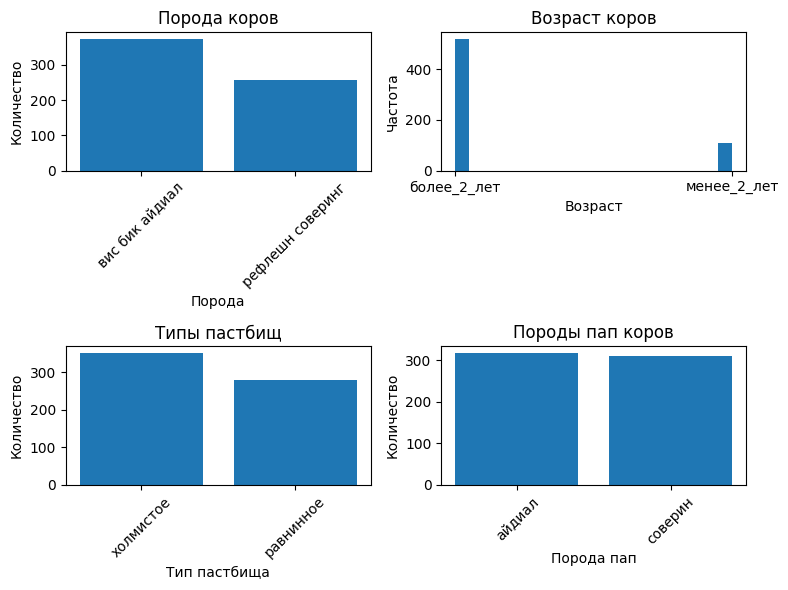

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# 1. Порода коров
counts = farm_data['breed'].value_counts()
axes[0, 0].bar(counts.index, counts.values)
axes[0, 0].set_title('Порода коров')
axes[0, 0].set_xlabel('Порода')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Возраст коров — гистограмма (числовой признак)
axes[0, 1].hist(farm_data['age'], bins=20)
axes[0, 1].set_title('Возраст коров')
axes[0, 1].set_xlabel('Возраст')
axes[0, 1].set_ylabel('Частота')

# 3. Тип пастбища
counts = farm_data['pasture_type'].value_counts()
axes[1, 0].bar(counts.index, counts.values)
axes[1, 0].set_title('Типы пастбищ')
axes[1, 0].set_xlabel('Тип пастбища')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Порода пап
counts = farm_data['dads_breed'].value_counts()
axes[1, 1].bar(counts.index, counts.values)
axes[1, 1].set_title('Породы пап коров')
axes[1, 1].set_xlabel('Порода пап')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Порода коров: вис бис айдиал больше, чем рефлешн соверинг

Возраст коров: коров, которым более 2 лет, значительно больше в сравнении с молодыми, которым не исполнилось 2 лет

Тип пастбищ: холмистый тип пастбищ преобладает над равнинным

Порода пап коров: айдиал и соверин приблизительно равны 

In [28]:
def get_histogram_boxplot(column_data, title, bins=10):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Box Plot", "Histogram"],
        specs=[[{"type": "box"}, {"type": "histogram"}]]
    )
    fig.add_trace(
        go.Box(y=column_data, name='Box Plot'),
        row=1, col=1
    )
    fig.add_trace(
        go.Histogram(x=column_data, name='Histogram', nbinsx=bins),
        row=1, col=2
    )
    fig.update_layout(
        title=title,
        template='seaborn'
    )
    return fig 

In [29]:
fig = get_histogram_boxplot(
    farm_data['milk_yield'], 
    'Годовой удой молока на одну корову', 
    bins=200
)

fig.update_layout(
    xaxis_title="Годовой удой, кг",
    yaxis_title="Число коров",

    xaxis2_title="Годовой удой, кг",
    yaxis2_title="Распределение удоев",
    
    yaxis=dict(range=[5000, 7500]),  
    xaxis2=dict(range=[5000, 7500]),   
    yaxis2=dict(range=[0, 17]),        
)

fig.show()

по графикам видно, что в среднем гдовой удой коровы лежит в промежутке от 5700 до 6500 кг

На обоих графиках видим, что есть выброс, равный больше 45000. Удой одной коровы в год не может быть таким, поэтому удалим его из таблицы. Также нужно не забыть удалить строчку по такому же id в датафрейме dads_data, чтобы потом перед тем, как приступить обучению модели, мы соединили две эти таблицы в одну по ключу id

In [30]:
farm_data[farm_data['milk_yield'] > 45000]

,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,breed,pasture_type,dads_breed,fat_content,protein,milk_taste,age
16,17,45616,11.5,1675,0.93,вис бик айдиал,холмистое,айдиал,3.22,3.076,вкусно,более_2_лет


In [31]:
farm_data = farm_data.query('milk_yield <= 7222')
dads_data = dads_data[~(dads_data['id'] == 17)]

fig = get_histogram_boxplot(
    farm_data['milk_yield'], 
    'Масса молока, которую корова даёт в год', 
    bins=200
)

fig.update_layout(
    yaxis_title="Масса молока (кг/год)",
    xaxis2_title="Масса молока (кг/год)", 
    yaxis2_title="Количество коров"    
)

In [32]:
print(farm_data.shape[0])
print(dads_data.shape[0])

628
628


Количество строчек совпадает, значит, мы не удалили лишнего

In [33]:
fig = get_histogram_boxplot(
    farm_data['feed_energy'], 
    'ЭКЕ (Энергетическая кормовая единица)', 
    bins=100
)

fig.update_layout(
    yaxis_title="Значение ЭКЕ", 
    xaxis2_title="Значение ЭКЕ",        
    yaxis2_title="Частота встречаемости",  
)

fig.show()

значение эке в среднем 15, центр гистограммы смещен вправо 

In [34]:
fig = get_histogram_boxplot(
    farm_data['fat_content'], 
    'Содержание жиров в молоке (в процентах)',
    bins=100
)

fig.update_layout(
    yaxis_title="Содержание жира, %",     
    xaxis2_title="Содержание жира, %",
    yaxis2_title="Количество проб",      
)


процент жира зачастую равен больше 3, но выше 4 не поднимается. 

In [35]:
fig = get_histogram_boxplot(
    farm_data['sugar_protein_ratio'], 
    'СПО (сахаро-протеиновое соотношение) в корме коровы',
    bins=100
)

fig.update_layout(
    yaxis_title="Значение СПО",          
    xaxis2_title="Значение СПО",             
    yaxis2_title="Частота встречаемости",
)
fig.show()

значение спо часто лежит в интервале от 0,89 до 0,95 

график гистограммы идет на повышение 

In [36]:
fig = get_histogram_boxplot(
    farm_data['fat_content'], 
    'Содержание жиров в молоке (в процентах)',
    bins=100
)

fig.update_layout(
    yaxis_title="Содержание жира, %",
    xaxis2_title="Содержание жира, %",      
    yaxis2_title="Количество проб",          
)

fig.show()

содержание белков начинается с 3% и имеет высокую концентрацию в промежутке от 3,6 до 3,8 

Построим гистограммы для категориальных признаков в cows_data

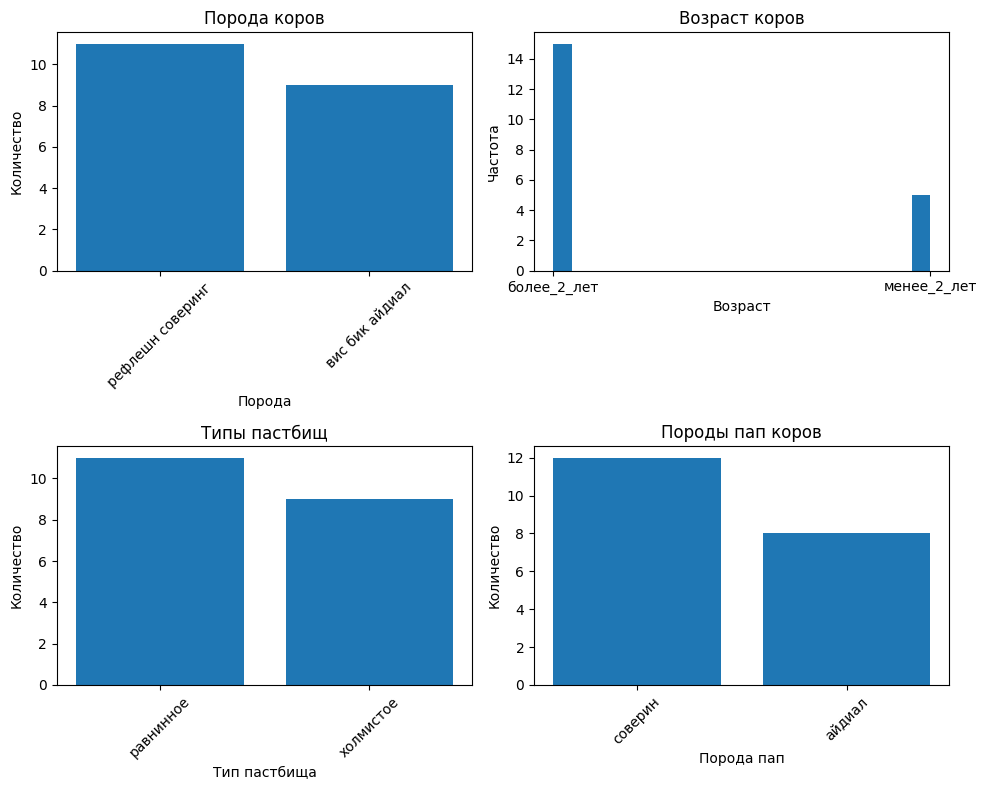

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Порода коров — bar
counts = cows_data['breed'].value_counts()
axes[0, 0].bar(counts.index, counts.values)
axes[0, 0].set_title('Порода коров')
axes[0, 0].set_xlabel('Порода')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Возраст коров — histogram (числовой признак)
axes[0, 1].hist(cows_data['age'], bins=20)
axes[0, 1].set_title('Возраст коров')
axes[0, 1].set_xlabel('Возраст')
axes[0, 1].set_ylabel('Частота')

# 3. Тип пастбища — bar
counts = cows_data['pasture_type'].value_counts()
axes[1, 0].bar(counts.index, counts.values)
axes[1, 0].set_title('Типы пастбищ')
axes[1, 0].set_xlabel('Тип пастбища')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Порода пап — bar
counts = cows_data['dads_breed'].value_counts()
axes[1, 1].bar(counts.index, counts.values)
axes[1, 1].set_title('Породы пап коров')
axes[1, 1].set_xlabel('Порода пап')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Порода коров:примерно равны вис бис фйдиал и рефлен соверинг

возраст коров: в три раза больше коров, котором уже есть 2 года 

тип пастбища: равнинное чуть распространенее, чем холмистое

породы пап коров: соверин в 1.5 раз больше, чем айдиал



In [38]:
fig = get_histogram_boxplot(
    farm_data['fat_content'], 
    'Текущая жирность в молоке на момент продажи',
    bins=30
)

fig.update_layout(
    yaxis_title="Жирность молока, %",         
    xaxis2_title="Жирность молока, %",        
    yaxis2_title="Количество поставок",      
)

fig.show()

жирность молока на момент продажи принадлежит отрезку, начиная от 3,6 до 3,8. бывает и меньше, но в редких случаях 

In [39]:
fig = get_histogram_boxplot(
    farm_data['protein'], 
    'Текущий уровень белков в молоке на момент продажи',
    bins=30
)

fig.update_layout(
    yaxis_title="Содержание белка, %",        
    xaxis2_title="Содержание белка, %",  
    yaxis2_title="Количество проб",     
)

fig.show()

распределение по гистограмме нормальное. в среднем уровень белка равен 3.076%

In [40]:
fig = px.histogram(dads_data,
                   y="dads_name",
                   title='Папы коров на момент продажи',
                   labels={'dads_name': 'Имена пап коров'},
                   template='seaborn')

fig.show()

популярными именами коров считаются барин и затем буйный. в 2 раза меньше соловчик. и на последнем месте геркулес

### Вывод
Средний удой коров в год равен 6132 кг.
График питательности корма смещен вправо, средняя питательность корма 14,7;

График содержания сырого протеина в корме смещен влево, среднее значение 
содержания сырого протеина равно 1888;

Среднее значение сахаро-протеинового отношения в корме коровы равно 0,93;

Среднее содержание жиров в молоке равно 3,65 в farm_data;

Среднее содержание белков в молоке равно 3, 076 в farm_data;

Коров, чей возраст более 2 лет, в пять раз больше, чем коров младше 2 8.Самое популярное имя среди пап коров - Барин

# Шаг 4. Корреляционный анализ признаков

Найдем коэффициенты корреляции между количественными признаками

In [41]:
selected_columns = [
    'milk_yield',
    'feed_energy',
    'crude_protein',
    'sugar_protein_ratio',
    'fat_content',
    'protein'
]

normality_results = {}
for col in selected_columns:
    stat, p = stats.shapiro(farm_data[col].dropna())
    normality_results[col] = p > 0.05

print("Результаты проверки нормальности распределения:")
for col, is_normal in normality_results.items():
    print(f"{col}: {'Нормальное' if is_normal else 'Ненормальное'} распределение")

correlation_method = 'pearson' if all(normality_results.values()) else 'spearman'

coeff_matrix = farm_data[selected_columns].corr(method=correlation_method)
coeff_matrix

Результаты проверки нормальности распределения:
milk_yield: Ненормальное распределение
feed_energy: Ненормальное распределение
crude_protein: Ненормальное распределение
sugar_protein_ratio: Ненормальное распределение
fat_content: Ненормальное распределение
protein: Ненормальное распределение


,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,fat_content,protein
milk_yield,1.000000,0.765144,0.437543,0.787904,0.688506,-0.005701
feed_energy,0.765144,1.000000,0.384747,0.741962,0.686973,-0.013321
crude_protein,0.437543,0.384747,1.000000,0.485890,0.392822,0.229051
sugar_protein_ratio,0.787904,0.741962,0.485890,1.000000,0.701044,0.109924
fat_content,0.688506,0.686973,0.392822,0.701044,1.000000,0.043125
protein,-0.005701,-0.013321,0.229051,0.109924,0.043125,1.000000


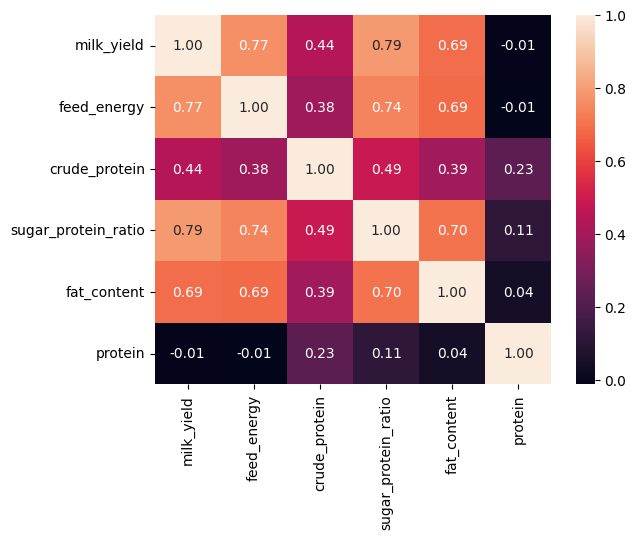

In [42]:
sns.heatmap(coeff_matrix, annot=True, fmt='.2f')
plt.show()

In [43]:
def make_scatterplots(colors_dict, category_name, name):
  features = ['feed_energy', 'crude_protein', 'sugar_protein_ratio', 'fat_content', 'protein']
  fig = make_subplots(rows=3, cols=2,
                    subplot_titles=features)

  i = 0
  for row in range(1, 4):
      for col in range(1, 3):
          if i < len(features):
              feature = features[i]
              fig.add_trace(
                  go.Scatter(
                      x=farm_data['milk_yield'],
                      y=farm_data[feature],
                      mode='markers',
                      marker=dict(size=10, color=[colors_dict[cat] for cat in farm_data[category_name]]),
                      showlegend=False
                  ),
                  row=row, col=col
              )
              i += 1

  fig.update_layout(
      title=name,
      height=800,
      width=1200,
      template='seaborn'
  )

  fig.show()

In [44]:
breed_colors = {
    'вис бик айдиал': px.colors.qualitative.Plotly[2],
    'рефлешн соверинг': px.colors.qualitative.Plotly[3]
}
make_scatterplots(breed_colors, 'breed', 'Соотношение удоя коров с другими признаками с учетом породы')

In [45]:
pasture_colors = {
    'равнинное': px.colors.qualitative.Plotly[3],
    'холмистое': px.colors.qualitative.Plotly[4]
}
make_scatterplots(pasture_colors, 'pasture_type', 'Соотношение удоя коров с другими признаками с учетом типа пастбища')

In [46]:
dads_breed_colors = {
    'айдиал': px.colors.qualitative.Plotly[0],
    'соверин': px.colors.qualitative.Plotly[1]
}
make_scatterplots(dads_breed_colors, 'dads_breed', 'Соотношение удоя коров с другими признаками с учетом породы папы коровы')

In [47]:
# Преобразуем строковые значения в числовые
farm_data['milk_taste_num'] = farm_data['milk_taste'].map({'вкусно': 1, 'не вкусно': 0})

milk_taste_colors = {
    1: px.colors.qualitative.Plotly[5], 
    0: px.colors.qualitative.Plotly[6]
}

make_scatterplots(milk_taste_colors, 'milk_taste_num', 'Соотношение удоя коров с другими признаками с учетом вкуса молока')

In [48]:
age_colors = {
    'более_2_лет': px.colors.qualitative.Plotly[9],
    'менее_2_лет': px.colors.qualitative.Plotly[2]
}
make_scatterplots(age_colors, 'age', 'Соотношение удоя коров с другими признаками с учетом возраста коровы')

### Вывод

Есть высокая линейная зависимость между удоем коровы и питательностью корма коровы, коэффициент равен 0,77;

Линейная зависимость между удоем коровы и содержанием сырого протеина в корме коровы слабая, она равна 0,44;

Между удоем коровы и СПО (сахаро-протеиновым отношением) нет линейной связи, так как признак СПО принимает дискретные значения, из определенного набора чисел, более категориальный признак;

Есть средняя линейная зависимость между удоем коровы и содержанием жиров в молоке, коэффициент равен 0,6. Объясняется тем, что большая часть коров дает жирное молоко;

Нет связи между удоем коровы и содержанием белков в молоке;
Мультиколлинеарность между входными признаками не наблюдается.

# Шаг 5. Задача регрессии

Первая модель

В качестве целевого признака у нас milk_yield удой коровы, а за входные признаки возьмем следующие столбцы:

breed - думаю, что от породы зависит, какое количество молока корова будет производить в год;


pasture_type - тип пастбища влияет на состояние коровы;

dads_breed - от породы папы коровы зависит, какие гены унаследует корова

age - от возраста коровы завивит, какое количество молока она будет 
производить. обычно, молодые особи приносят меньше, чем взрослые коровы

feed_energy - есть сильная линейная зависимость удоя коровы от питательности 
корма, как мы выяснили раньше. логично, что если корм будет не достаточно 
питательный, то корова будет производить меньше молока;

crude_protein - слабая линейная зависимость удоя коровы от содержания сырого 
протеина в корме коровы;

sugar_protein_ratio - нет линейной зависимости, но содержание сахара в корме коровы тоже может влиять на массу молока, которую производит корова.

In [49]:
def run_model_lr(data, cat_col_names, num_col_names):
    df = data.copy()
    RANDOM_STATE = 42
    X = df.drop('milk_yield', axis=1)
    y = df['milk_yield']
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=RANDOM_STATE
    )
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])
    encoder_col_names = encoder.get_feature_names_out()

    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

    model_lr = LinearRegression()

    model_lr.fit(X_train, y_train)

    predictions = model_lr.predict(X_test)

    return model_lr, predictions, y_test, encoder, scaler

In [50]:
# Метрики
def compute_r2_score(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    return r2

def compute_mse_score(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse

def compute_mae_score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    return mae

def compute_rmse_score(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    return rmse

In [51]:
cat_col_names_1 = ['breed', 'pasture_type', 'dads_breed', 'age']
num_col_names_1 = ['feed_energy', 'crude_protein', 'sugar_protein_ratio']
model_lr_1, predictions_1, y_true_1, encoder_1, scaler_1 = run_model_lr(farm_data, cat_col_names_1, num_col_names_1)
r2_score_1 = compute_r2_score(y_true_1, predictions_1)
mse_score_1 = compute_mse_score(y_true_1, predictions_1)
mae_score_1 = compute_mae_score(y_true_1, predictions_1)
rmse_score_1 = compute_rmse_score(y_true_1, predictions_1)
print(f'R2: {r2_score_1}')
print(f'MSE: {mse_score_1}')
print(f'MAE: {mae_score_1}')
print(f'RMSE: {rmse_score_1}')

R2: 0.7844078173416967
MSE: 43887.01500966051
MAE: 164.2419446347492
RMSE: 209.4922791170608


Значение коэффициента детерминации близко к единице — модель хорошо себя показывает в 78 процентах случаев.

Проведем анализ остатков

In [52]:
residuals_df_1 = pd.DataFrame({'y_test': y_true_1, 'predictions': predictions_1})

residuals_df_1['residuals'] = residuals_df_1['y_test'] - residuals_df_1['predictions']
residuals_df_1

,y_test,predictions,residuals
582,5980,6031.538081,-51.538081
592,6512,6433.102409,78.897591
551,5392,5459.599755,-67.599755
214,5604,5655.815895,-51.815895
486,5667,5978.908819,-311.908819
...,...,...,...
84,6686,6684.643573,1.356427
285,6967,6588.211688,378.788312
577,6248,6495.865174,-247.865174
80,5640,6195.785985,-555.785985


In [53]:
def get_residuals(df, bins):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Анализ дисперсии", "Распределение остатков"],
        specs=[[{"type": "scatter"}, {"type": "histogram"}]]
    )
    fig.add_trace(
        go.Scatter(x=df['predictions'],
                   y=df['residuals'],
                   mode='markers',
                   name='Дисперсия остатков'),
        row=1, col=1
    )

    fig.add_trace(
        go.Histogram(x=df['residuals'], name='Распределение остатков', nbinsx=bins),
        row=1, col=2
    )

    fig.update_layout(
        title='Анализ остатков модели',
        template='seaborn'
    )

    fig.update_xaxes(title_text="Предсказания модели", row=1, col=1)
    fig.update_yaxes(title_text="Остатки модели", row=1, col=1)
    fig.update_xaxes(title_text="Остатки модели", row=1, col=2)

    fig.show()

In [54]:
get_residuals(residuals_df_1, 30)

Остатки нормально распределены, но график несимметричен со смещением влево: модель переоценивает реальные значения целевого признака, её прогнозы больше фактических показателей. -Разница между минимумом и максимумом остатков при любых прогнозных значениях модели разная. Дисперсия между значениями на оси Y непостоянна на протяжении всей оси X. Модель на больших значениях предсказаний целевого признака либо неоценивает, либо переоценивает.

### Вторая модель

In [55]:
fig = px.scatter(farm_data,
             x='milk_yield',
             y="sugar_protein_ratio",
             title='Зависимость удоя коровы от СПО')

fig.update_xaxes(title_text="Удой коровы")
fig.update_yaxes(title_text="Сахаро-протеиновое отношение")
fig.show()

Как мы выяснили раньше, между удоем коровы и СПО в корме коровы нет линейной зависимости. На их диаграмме рассеяния наблюдения сгруппированы в два кластера, которые значение СПО=0,91 делит, поэтому преобразуем СПО в категориальный бинарный признак, использовав эту границу.

In [56]:
farm_data['spr_binary'] = farm_data['sugar_protein_ratio'].apply(
                          lambda x: 'более_0.91' if x > 0.91 else 'менее_0.91')

Построим диаграмму рассеяния для ЭКЕ и удоя коровы

In [57]:
fig = px.scatter(farm_data,
             x='milk_yield',
             y="feed_energy",
             title='Зависимость удоя коровы от ЭКЕ')

fig.update_xaxes(title_text="Удой коровы")
fig.update_yaxes(title_text="ЭКЕ (Энергетическая кормовая единица)")
fig.show()

In [58]:
farm_data['square_feed_energy'] = farm_data['feed_energy'] ** 2

Построим диаграмму рассеяния для ЭКЕ в квадрате и удоя коровы

In [59]:
fig = px.scatter(farm_data,
             x='milk_yield',
             y="square_feed_energy",
             title='Зависимость удоя коровы от ЭКЕ в квадрате')

fig.update_xaxes(title_text="Удой коровы")
fig.update_yaxes(title_text="($ЭКЕ^2$) (Энергетическая кормовая единица)")
fig.show()

In [60]:
cat_col_names_2 = ['breed', 'pasture_type', 'dads_breed', 'age', 'spr_binary']
num_col_names_2 = ['square_feed_energy', 'crude_protein']
model_lr_2, predictions_2, y_true_2, encoder_2, scaler_2 = run_model_lr(farm_data, cat_col_names_2, num_col_names_2)
r2_score_2 = compute_r2_score(y_true_2, predictions_2)
mse_score_2 = compute_mse_score(y_true_2, predictions_2)
mae_score_2 = compute_mae_score(y_true_2, predictions_2)
rmse_score_2 = compute_rmse_score(y_true_2, predictions_2)
print(f'R2: {r2_score_2}')
print(f'MSE: {mse_score_2}')
print(f'MAE: {mae_score_2}')
print(f'RMSE: {rmse_score_2}')

R2: 0.8180879926867504
MSE: 37030.91131113693
MAE: 149.03965222364593
RMSE: 192.43417396901447


Метрика r2 у второй модели чуть выше, чем у первой. Вторая модель ошибается только 19 процентах случаев.

In [61]:
residuals_df_2 = pd.DataFrame({'y_test': y_true_2, 'predictions': predictions_2})

residuals_df_2['residuals'] = residuals_df_2['y_test'] - residuals_df_2['predictions']
residuals_df_2

,y_test,predictions,residuals
582,5980,5944.278142,35.721858
592,6512,6466.655661,45.344339
551,5392,5518.937220,-126.937220
214,5604,5621.103104,-17.103104
486,5667,5871.197725,-204.197725
...,...,...,...
84,6686,6738.078748,-52.078748
285,6967,6581.308849,385.691151
577,6248,6502.184832,-254.184832
80,5640,6049.464475,-409.464475


In [62]:
get_residuals(residuals_df_2, 30)

Все еще есть смещение влево, значит, что модель переоценивает значения целевого признака. Самое частое значение - 0.
Дисперсия остатков все еще увеличивается на больших значениях.

### Третья модель

In [63]:
cat_col_names_3 = ['breed', 'pasture_type', 'dads_breed', 'age', 'spr_binary']
num_col_names_3 = ['square_feed_energy', 'crude_protein']

X = farm_data.drop('milk_yield', axis=1)
y = farm_data['milk_yield']
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE
)

encoder_3 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe_3 = encoder_3.fit_transform(X_train[cat_col_names_3])
X_test_ohe_3 = encoder_3.transform(X_test[cat_col_names_3])
encoder_col_names_3 = encoder_3.get_feature_names_out()

X_train_ohe_3 = pd.DataFrame(X_train_ohe_3, columns=encoder_col_names_3)
X_test_ohe_3 = pd.DataFrame(X_test_ohe_3, columns=encoder_col_names_3)

scaler_3 = StandardScaler()
X_train_scaled_3 = scaler_3.fit_transform(X_train[num_col_names_3])
X_test_scaled_3 = scaler_3.transform(X_test[num_col_names_3])

X_train_scaled_3 = pd.DataFrame(X_train_scaled_3, columns=num_col_names_3)
X_test_scaled_3 = pd.DataFrame(X_test_scaled_3, columns=num_col_names_3)

X_train_3 = pd.concat([X_train_ohe_3, X_train_scaled_3], axis=1)
X_test_3 = pd.concat([X_test_ohe_3, X_test_scaled_3], axis=1)

model_lr_3 = LinearRegression()
model_lr_3.fit(X_train_3, np.log1p(y_train))

predictions_3 = np.expm1(model_lr_3.predict(X_test_3))

r2_score_3 = r2_score(y_test, predictions_3)
mse_score_3 = mean_squared_error(y_test, predictions_3)
mae_score_3 = mean_absolute_error(y_test, predictions_3)
rmse_score_3 = root_mean_squared_error(y_test, predictions_3)

print(f'R2: {r2_score_3}')
print(f'MSE: {mse_score_3}')
print(f'MAE: {mae_score_3}')
print(f'RMSE: {rmse_score_3}')

R2: 0.8253662369461957
MSE: 35549.31577682893
MAE: 145.46420488399642
RMSE: 188.5452618784915


Метрика r2 у третьей модели чуть выше, чем у второй. Третья модель ошибается только 18 процентах случаев.

In [64]:
residuals_df_3 = pd.DataFrame({
    'y_test': y_test.values,
    'predictions': predictions_3,
})

residuals_df_3['residuals'] = residuals_df_3['y_test'] - residuals_df_3['predictions']
residuals_df_3

,y_test,predictions,residuals
0,5980,5929.956491,50.043509
1,6512,6459.261697,52.738303
2,5392,5502.787243,-110.787243
3,5604,5644.726014,-40.726014
4,5667,5866.681931,-199.681931
...,...,...,...
152,6686,6737.994146,-51.994146
153,6967,6571.214288,395.785712
154,6248,6498.988499,-250.988499
155,5640,6030.599146,-390.599146


In [65]:
get_residuals(residuals_df_3, 30)

На больших значениях дисперсия увелчивается;

Дисперсия между значениями на оси Y непостоянна

In [66]:
interval = stats.norm.interval(confidence= 0.95 , loc=np.mean(predictions_3), scale=stats.sem(predictions_3))

print(f'Доверительный интервал модели: {interval[0].round(2)} - {interval[1].round(2)}')

Доверительный интервал модели: 6097.83 - 6223.3


### Прогноз удоя коров

In [67]:
# Средние значения кормовых признаков по ферме (+5% на улучшение кормления)
mean_feed_energy = farm_data['feed_energy'].mean() * 1.05
mean_crude_protein = farm_data['crude_protein'].mean() * 1.05
mean_spr = farm_data['sugar_protein_ratio'].mean() * 1.05

# Применяем эти значения ко всем покупаемым коровам
cows_data['square_feed_energy'] = (mean_feed_energy ** 2).round(2)
cows_data['crude_protein'] = mean_crude_protein.round(2)
cows_data['sugar_protein_ratio'] = mean_spr

# Бинаризация СПО (порог 0.91 выбран ранее при анализе farm_data)
cows_data['spr_binary'] = cows_data['sugar_protein_ratio'].apply(
    lambda x: 'более_0.91' if x > 0.91 else 'менее_0.91'
)

cows_data.head()

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,square_feed_energy,crude_protein,sugar_protein_ratio,spr_binary
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.36,2019.95,0.958744,более_0.91
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,233.36,2019.95,0.958744,более_0.91
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.36,2019.95,0.958744,более_0.91
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91


In [68]:
# Кодируем категориальные признаки с помощью обученного энкодера
data_ohe = encoder_3.transform(cows_data[cat_col_names_3])
encoder_col_names = encoder_3.get_feature_names_out()
data_ohe = pd.DataFrame(data_ohe, columns=encoder_col_names)

# Масштабируем числовые признаки с помощью обученного скейлера
data_scaled = scaler_3.transform(cows_data[num_col_names_3])
data_scaled = pd.DataFrame(data_scaled, columns=num_col_names_3)

# Объединяем признаки
final_data = pd.concat([data_ohe, data_scaled], axis=1)

# Делаем прогноз (модель обучена на log1p целевого признака, поэтому нужен обратный expm1)
final_predictions_log = model_lr_3.predict(final_data)
final_predictions = np.expm1(final_predictions_log)

# Записываем прогноз в столбец milk_yield
cows_data['milk_yield'] = final_predictions

cows_data.head()

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,square_feed_energy,crude_protein,sugar_protein_ratio,spr_binary,milk_yield
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.36,2019.95,0.958744,более_0.91,6544.876585
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,233.36,2019.95,0.958744,более_0.91,6039.262540
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91,6307.761913
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.36,2019.95,0.958744,более_0.91,6545.778943
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91,6516.128367


Отберем те коровы, чей удой в год не менее 6000 килограммов

In [69]:
cows_data[cows_data['milk_yield'] > 6000]

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,square_feed_energy,crude_protein,sugar_protein_ratio,spr_binary,milk_yield
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.36,2019.95,0.958744,более_0.91,6544.876585
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,233.36,2019.95,0.958744,более_0.91,6039.262540
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91,6307.761913
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,233.36,2019.95,0.958744,более_0.91,6545.778943
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91,6516.128367
5,рефлешн соверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,233.36,2019.95,0.958744,более_0.91,6040.095199
6,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,233.36,2019.95,0.958744,более_0.91,6544.876585
7,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,233.36,2019.95,0.958744,более_0.91,6306.892361
8,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,233.36,2019.95,0.958744,более_0.91,6307.761913
9,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,233.36,2019.95,0.958744,более_0.91,6268.013697


### Вывод

С помощью модели model_lr_3 спрогнозирован годовой удой для 20 коров из cow_buy.csv. Прогнозы лежат в диапазоне 6040–6545 кг, все коровы превышают порог в 6000 кг.

Из-за отсутствия данных о кормлении в cow_buy.csv для всех коров использованы одинаковые средние кормовые признаки. Поэтому прогноз различается только по породе, типу пастбища, породе папы и возрасту: коровы с одинаковой комбинацией этих признаков получают одинаковый прогноз (например, 6307.8 кг или 6544.9 кг). Это следствие допущения, а не ошибка модели.

# Шаг 6. Задача классификации

In [70]:
farm_data['milk_taste'] = (
    farm_data['milk_taste']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'вкусно': 1, 'не вкусно': 0})
)

print(farm_data['milk_taste'].value_counts())

milk_taste
1    370
0    258
Name: count, dtype: int64


In [71]:
cat_col_names_4 = ['breed', 'pasture_type', 'dads_breed', 'age', 'spr_binary']
num_col_names_4 = ['square_feed_energy', 'crude_protein', 'fat_content', 'protein', 'milk_yield']

In [72]:
farm_df = farm_data.copy()

RANDOM_STATE = 42

X = farm_df.drop('milk_taste', axis=1)
y = farm_df['milk_taste']

X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      random_state=RANDOM_STATE
)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names_4])
X_test_ohe = encoder.transform(X_test[cat_col_names_4])
encoder_col_names = encoder.get_feature_names_out()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names_4])
X_test_scaled = scaler.transform(X_test[num_col_names_4])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_4)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_4)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

clf = LogisticRegression()

clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [73]:
acc = accuracy_score(y_test, y_pred)
recall =  recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f'Accuracy: {acc}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')

Accuracy: 0.6369426751592356
Recall: 0.8636363636363636
Precision: 0.628099173553719


Построим матрицу ошибок

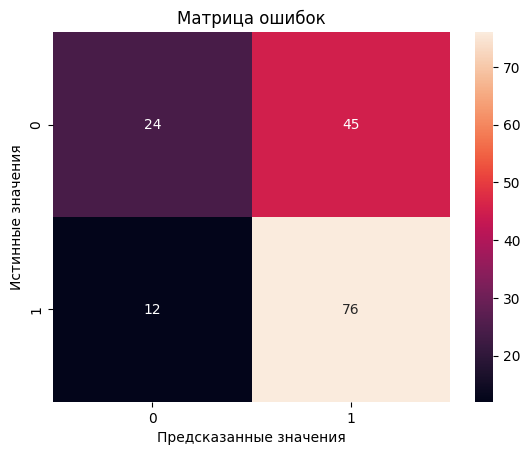

In [74]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Матрица ошибок')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

Модель 45 раз ошибочно предсказывает «вкусно» (FP, ошибка I рода) и 12 раз ошибочно предсказывает «не вкусно» (FN, ошибка II рода). Так как для заказчика главное — не купить корову с невкусным молоком, критичной является ошибка I рода: если модель скажет «вкусно», а молоко окажется невкусным, фермер понесёт убытки.

Precision = 0.63 показывает, какая доля предсказаний «вкусно» оказалась верной. Чем выше Precision, тем реже модель называет вкусной невкусную корову. У нас 63 % — приемлемо, но есть куда улучшать.

Recall = 0.86 показывает, какую долю реальных «вкусных» коров модель нашла. У нас модель находит 86 % вкусных, но пропускает 14 % (12 коров из 88).

Чтобы свести ошибку I рода к нулю, изменим порог принадлежности к классу «вкусно» — поднимем его с 0.5 до значения, при котором FP = 0.

Сведем критичную ошибку к нулю: для этого изменим порог принадлежности к классам.

In [75]:
proba = clf.predict_proba(X_test)[:, 1]

best_thr = None
for thr in np.arange(0.5, 1.0, 0.005):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    if fp == 0 and tp > 0:
        best_thr = thr
        break

print('Порог с FP = 0:', best_thr)

pred_best = (proba >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_best, labels=[0, 1]).ravel()

print(f'TP={tp}, FP={fp}, FN={fn}, TN={tn}')
print(f'Accuracy:  {accuracy_score(y_test, pred_best):.4f}')
print(f'Recall:    {recall_score(y_test, pred_best):.4f}')
print(f'Precision: {precision_score(y_test, pred_best):.4f}')

Порог с FP = 0: 0.7900000000000003
TP=11, FP=0, FN=77, TN=69
Accuracy:  0.5096
Recall:    0.1250
Precision: 1.0000


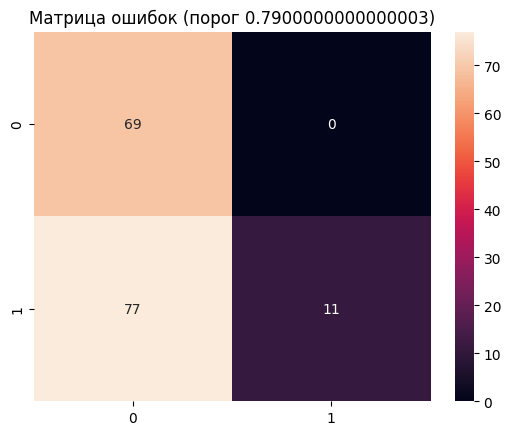

In [76]:
cm_best = confusion_matrix(y_test, pred_best)
sns.heatmap(cm_best, annot=True, fmt='d')
plt.title(f'Матрица ошибок (порог {best_thr})')
plt.show()

In [77]:
cows_data = cows_data.copy()

for col in cows_data.select_dtypes(include='object').columns:
    cows_data[col] = cows_data[col].str.strip().str.lower()

data_ohe = encoder.transform(cows_data[cat_col_names_4])
data_ohe = pd.DataFrame(data_ohe, columns=encoder.get_feature_names_out())

data_scaled = scaler.transform(cows_data[num_col_names_4])
data_scaled = pd.DataFrame(data_scaled, columns=num_col_names_4)

final_data = pd.concat([data_ohe, data_scaled], axis=1)

cows_proba = clf.predict_proba(final_data)[:, 1]

cows_data['milk_taste'] = (cows_proba >= best_thr).astype(int)

print(cows_data[['milk_taste']].value_counts())
print('Максимум вероятности «вкусно»:', cows_proba.max())
print('Найденный порог:', best_thr)

milk_taste
0             20
Name: count, dtype: int64
Максимум вероятности «вкусно»: 0.742818128649048
Найденный порог: 0.7900000000000003


Модель логистической регрессии показала приемлемое качество при стандартном пороге 0.5, но для заказчика важнее минимизировать риск покупки невкусной коровы. Поэтому выбран порог 0.79, при котором FP = 0 и Precision = 1.0. Это означает, что если модель говорит «вкусно» — молоко действительно вкусное. Однако Recall при этом падает до 0.125, поэтому модель будет отбирать очень мало коров.

# Шаг 7. Итоговые выводы

## Результаты работы моделей

### Модель линейной регрессии (прогноз удоя)
- **R² = 0.825** — модель объясняет 82.5% дисперсии годового удоя.
- **MAE = 145.5 кг**, **RMSE = 188.5 кг** — средняя ошибка прогноза около 145–190 кг.
- Прогнозы для 20 коров из cow_buy.csv лежат в диапазоне **6040–6545 кг/год**.
- Все коровы превышают порог 6000 кг, но прогнозы различаются только по породе, типу пастбища, породе папы и возрасту — кормовые признаки взяты как средние по ферме (+5%), так как в `cow_buy.csv` этих данных нет.

### Модель логистической регрессии (прогноз вкуса молока)
- При пороге 0.5: **Accuracy = 0.637**, **Recall = 0.864**, **Precision = 0.628**.
- Критичная ошибка — **I рода (FP)**: модель говорит «вкусно», а молоко невкусное. Для заказчика это прямой риск убытков.
- Для сведения FP к нулю порог поднят до **0.79**: **Precision = 1.0**, **Recall = 0.125**, **FP = 0**.
- Модель стала слишком консервативной: при пороге 0.79 ни одна корова не проходит отбор по вкусу.

## Сколько коров фермер может купить с минимальным риском?

**Ответ: 0 коров** при строгом пороге 0.79.

Причина: максимальная прогнозируемая вероятность «вкусно» для коров из cow_buy.csv составляет **0.743**, что ниже порога 0.79. Модель не уверена ни в одной корове, поэтому с минимальным риском (FP = 0) купить никого нельзя.

**Компромиссный вариант:** снизить порог до **0.5–0.6**, тогда часть коров пройдёт отбор, но появится риск купить невкусную корову. Фермеру нужно решить, что важнее — гарантия качества или количество покупок.

## Рекомендации фермеру

1. **Собрать данные о кормлении** для коров из cow_buy.csv — это ключевой признак для прогноза удоя и вкуса. Без него модель работает на средних значениях.
2. **Использовать компромиссный порог** (0.6–0.7) для классификации вкуса, чтобы получить хоть какое-то количество коров для покупки.
3. **Провести дополнительный осмотр** отобранных коров (анализ молока, здоровье, условия содержания) перед покупкой.
4. **Рассмотреть покупку коров с высоким удоем** даже при неопределённом вкусе, если фермер готов перерабатывать молоко (сыр, творог), где вкус менее критичен.
5. **Расширить выборку** — 20 коров из cow_buy.csv слишком мало для надёжного отбора.

## Выводы о моделях

### Линейная регрессия
- Хорошо объясняет удой (R² = 0.825), но есть гетероскедастичность — дисперсия остатков растёт с увеличением прогноза.
- Основные признаки: ЭКЕ², сырой протеин, порода, тип пастбища, возраст.
- Логарифмирование целевого признака и добавление полиномиального признака (ЭКЕ²) улучшили качество.

### Логистическая регрессия
- Чувствительна к порогу: это позволяет управлять балансом между риском (FP) и количеством отобранных коров (Recall).
- При пороге 0.5 — хороший Recall, но высокий риск FP.
- При пороге 0.79 — нулевой риск FP, но почти нулевой Recall.

## Способы улучшения регрессионной модели

**Использованные в задаче:**
1. Логарифмирование целевого признака (np.log1p) — сглаживает выбросы.
2. Добавление полиномиального признака (square_feed_energy = ЭКЕ²) — улавливает нелинейность.
3. Бинаризация СПО по порогу 0.91.
4. Масштабирование количественных признаков (StandardScaler).
5. OneHotEncoder для категориальных признаков.

**Возможные улучшения:**
1. Добавить новые признаки: здоровье коровы, количество отёлов, сезон, условия содержания.
2. Использовать нелинейные модели: Random Forest, Gradient Boosting, нейронные сети.
3. Применить регуляризацию: Lasso, Ridge, ElasticNet.
4. Провести кросс-валидацию для подбора гиперпараметров.
5. Собрать данные о кормлении для cow_buy.csv — это главное ограничение текущей модели.

## Метрики классификации, важные при анализе рисков и экономических расчётов

1. **Precision** — критична при экономических расчётах: показывает, какая доля предсказаний «вкусно» верна. Высокий Precision = низкий риск купить невкусную корову.
2. **Recall** — важна, если цель — найти как можно больше вкусных коров.
3. **F1-мера** — баланс между Precision и Recall.
4. **ROC-AUC** — общая оценка качества модели независимо от порога.
5. **Precision-Recall AUC** — особенно полезна при дисбалансе классов.

**Итог:** для минимизации рисков при покупке коров важнее **Precision**, для максимизации количества найденных вкусных коров — **Recall**. В данной задаче выбран компромисс через настройку порога: порог 0.79 даёт Precision = 1.0, но Recall = 0.125, что означает высокую надёжность, но малое количество отобранных коров.